### Bayesian MC dropout query strategies

Bayesian query strategies use Monte Carlo (MC) dropout to approximate uncertainty in deep learning models. This works by computing multiple forward passes through a neural network with the dropout layers activated. For this example we are going to use a subset of [_MNIST_](https://archive.ics.uci.edu/dataset/683/mnist+database+of+handwritten+digits) dataset, loaded from _sklearn_.

In [ ]:
import numpy as np
import torch
from skorch import NeuralNetClassifier
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from activelearning.AL_cycle import plot_results, strategy_comparison
# from activelearning.queries.bayesian.mc_max_entropy import mc_max_entropy
from activelearning.queries.bayesian.mc_bald import mc_bald
from activelearning.queries.bayesian.mc_max_entropy import mc_max_entropy
from activelearning.queries.bayesian.mc_max_meanstd import mc_max_meanstd
from activelearning.queries.bayesian.mc_max_varratios import mc_max_varratios
from activelearning.queries.representative.random_query import query_random
from activelearning.utils.skorch_nnet import reshapedVGG

torch.manual_seed(123)
np.random.seed(123)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
import sys
import os
import numpy as np
import torch

PROJECT_ROOT = os.path.abspath("../..")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from al_data_process.data_preprocess import create_windowed_ts, map_class_label_to_idx
from al_data_process.dataset import stratified_sampling_train_val

window_length = 0.4
overlap = 0.25

invalid_classes = [14]
Xt_acc, Xt_gyr, Xt_mag, Xt_mic, y_org_label = create_windowed_ts(data_path="../../tool-tracking-data/",
                                                                     tool="electric_screwdriver",
                                                                     invalid_classes=invalid_classes,
                                                                     window_length = window_length,
                                                                     overlap = overlap)

all_classes, counts = np.unique(y_org_label, return_counts=True)

Xt_acc = Xt_acc[:, :, 1:].astype(np.float32)
Xt_gyr = Xt_gyr[:, :, 1:].astype(np.float32)
Xt_mag = Xt_mag[:, :, 1:].astype(np.float32)
Xt_mic = Xt_mic[:, :, 1:].astype(np.float32)

y = map_class_label_to_idx(y_org_label)

train_set, test_set = stratified_sampling_train_val(torch.from_numpy(Xt_acc),
                                                  torch.from_numpy(Xt_gyr),
                                                  torch.from_numpy(Xt_mag),
                                                  torch.from_numpy(Xt_mic),
                                                  torch.tensor(y))


X_pool = np.empty(len(train_set), dtype=object)
y_pool = np.empty(len(train_set))
for i in range(len(train_set)):
    X_pool[i] = train_set[i][0]
    y_pool[i] = train_set[i][1]


X_test = np.empty(len(test_set), dtype=object)
y_test = np.empty(len(test_set))
for i in range(len(test_set)):
    X_test[i] = test_set[i][0]
    y_test[i] = test_set[i][1]


Segment: 100%|██████████| 19380/19380 [00:00<00:00, 103709.86it/s]
[2 3 4 5 6 7 8] [ 546  234  199   89   50   59 3606]
count_1_14: 3, count_invalid_classes: 8, count_maj_vote: 46, count_diff_label: 5


We evaluate the performance of the classifier that we are going to use on the complete training set. This will serve as reference metric for the active learning query strategies, as we want to reach the same accuracy / f1 score but with less labeled data.

In [ ]:
num_lstm_layers = 1
hidden_size = 32
dropout_p = 0.3
num_classes = 7
lr = 2e-3
batch_size = 16
max_epochs = 100

In [5]:
from model.lstm_classif import LSTM_CLASSIF
from sklearn.metrics import f1_score
from skorch.dataset import CVSplit
from skorch.callbacks import EpochScoring, Checkpoint


def compute_class_weights_from_labels(y, beta=0.999):
    """
    Compute effective number class weights directly from labels.

    Args:
        y: array-like, shape (num_samples,)
           Class labels (int or float, discrete)
        beta: float, smoothing factor

    Returns:
        weights: np.array, shape (num_classes,)
    """
    classes, counts = np.unique(y, return_counts=True)
    classes = classes.astype(int)

    counts = counts.astype(np.float32)
    counts = np.maximum(counts, 1.0)

    effective_num = 1.0 - np.power(beta, counts)
    weights = (1.0 - beta) / effective_num

    weights = weights / weights.mean()

    num_classes = int(np.max(classes)) + 1
    full_weights = np.zeros(num_classes, dtype=np.float32)
    full_weights[classes] = weights

    return full_weights


class_weights = compute_class_weights_from_labels(y_pool, beta=0.999)
class_weights_tensor = torch.from_numpy(class_weights).float()


def collate_fn(batch):
    # separate features and labels
    x_batch, y_batch = zip(*batch)  # x_batch = list of tuples, y_batch = list of labels

    # transpose modalities
    acc, gyr, mag, mic = zip(*x_batch)  # each is a tuple of tensors

    # stack tensors along batch dimension (dim=0)
    acc = torch.stack(acc, dim=0)  # shape: (batch, time, features)
    gyr = torch.stack(gyr, dim=0)
    mag = torch.stack(mag, dim=0)
    mic = torch.stack(mic, dim=0)

    # convert labels to tensor
    if isinstance(y_batch[0], torch.Tensor):
        y_batch = torch.stack(y_batch).long()  # works if labels are 0-dim tensors
    else:
        y_batch = torch.tensor(y_batch, dtype=torch.long)


    return (acc, gyr, mag, mic), y_batch


# classifier = NeuralNetClassifier(
#     LSTM_CLASSIF(input_size=3, hidden_size=hidden_size, num_layers=num_lstm_layers, num_classes=num_classes,
#                              dropout_p=dropout_p),
#     criterion=torch.nn.CrossEntropyLoss,
#     criterion__weight=class_weights_tensor,
#     lr=lr,
#     batch_size=batch_size,
#     iterator_train__collate_fn=collate_fn,
#     iterator_valid__collate_fn=collate_fn,
#     optimizer=torch.optim.Adam,
#     train_split=None,
#     max_epochs=100,
#     device=device,
#     # train_loss_best=True,
# )

f1_cb = EpochScoring(
    scoring='f1_macro',      # sklearn scorer name
    lower_is_better=False,
    name='valid_f1',         # metric name in history
    on_train=False,          # compute on validation set
)

checkpoint = Checkpoint(
    monitor='valid_f1_best',
    # load_best=True,
    f_params='best_weights.pt',
)


classifier = NeuralNetClassifier(
    LSTM_CLASSIF(
        input_size=3,
        hidden_size=hidden_size,
        num_layers=num_lstm_layers,
        num_classes=num_classes,
        dropout_p=dropout_p,
    ),
    criterion=torch.nn.CrossEntropyLoss,
    criterion__weight=class_weights_tensor,
    optimizer=torch.optim.Adam,
    lr=lr,
    batch_size=batch_size,
    max_epochs=max_epochs,
    device=device,

    # train_split=ValidSplit(0.2, stratified=True),
    # train_split=CVSplit(0.2, stratified=True),
    train_split=CVSplit(0.15 / 0.85, stratified=True, random_state=42),

    iterator_train__collate_fn=collate_fn,
    iterator_valid__collate_fn=collate_fn,

    callbacks=[f1_cb, checkpoint],
)


classifier.fit(X_pool, y_pool)

classifier.load_params(f_params='best_weights.pt')

goal_acc = classifier.score(X_test, y_test)

y_pred = classifier.predict(X_test)
# print(y_pred.shape)
goal_f1 = f1_score(y_test, y_pred, average="macro")


print(f"Goal Accuracy: {goal_acc}")
print(f"Goal F1 Score: {goal_f1}")



# net = classifier.module_
# net.output_mode = "embedding"
# net.eval()

# with torch.no_grad():
#     emb = torch.cat(list(classifier.forward_iter(X_test, training=False)))

# net.output_mode = "logits"



  epoch    train_loss    valid_acc    valid_f1    valid_loss    cp     dur
-------  ------------  -----------  ----------  ------------  ----  ------
      1        1.4730       0.7730      0.3307        1.0947     +  1.4843
      2        1.0468       0.7758      0.4967        0.8278     +  1.3895
      3        0.9245       0.7758      0.4556        0.7489        1.4217
      4        0.7467       0.7702      0.5366        0.6874     +  1.3778
      5        0.8362       0.7549      0.4974        0.6620        1.3768
      6        0.7428       0.7702      0.4914        0.6393        1.3830
      7        0.7195       0.7493      0.4560        0.6381        1.3777
      8        0.6742       0.8078      0.5726        0.6166     +  1.3855
      9        0.6539       0.8134      0.5192        0.6962        1.3776
     10        0.6300       0.8008      0.5115        0.6071        1.3782
Goal Accuracy: 0.8119777158774373
Goal F1 Score: 0.5553012309271675


In [7]:
n_query = 400
selected_idx = np.random.choice(len(X_pool), size=n_query, replace=False)

X_initial = X_pool[selected_idx]
y_initial = y_pool[selected_idx]

X_pool = np.delete(X_pool, selected_idx, axis=0)
y_pool = np.delete(y_pool, selected_idx, axis=0)

To compare how different query strategies perform, we can use the *strategy_comparison* function and pass the strategies to be used. We can also pass more than one number of instances, to check whether a different batch size influences performance. *plot_results* can be used to immediatly plot the output from *strategy_comparison*, or a custom graph can be created from the scores data frame.

In [8]:
n_instances = [100]
goal_metric = "f1"
# goal_metric = "acc"

# classifier = NeuralNetClassifier(
#     LSTM_CLASSIF(input_size=3, hidden_size=hidden_size, num_layers=num_lstm_layers, num_classes=num_classes,
#                              dropout_p=dropout_p),
#     criterion=torch.nn.CrossEntropyLoss,
#     # criterion__weight=class_weights_tensor,
#     lr=2e-3,
#     batch_size=16,
#     iterator_train__collate_fn=collate_fn,
#     iterator_valid__collate_fn=collate_fn,
#     optimizer=torch.optim.Adam,
#     train_split=None,
#     max_epochs=100,
#     device=device,
# )


f1_cb_al = EpochScoring(
    scoring='f1_macro',      # sklearn scorer name
    lower_is_better=False,
    name='valid_f1',         # metric name in history
    on_train=False,          # compute on validation set
)

checkpoint_al = Checkpoint(
    monitor='valid_f1_best',
    # load_best=True,
    f_params='best_weights.pt',
)

classifier = NeuralNetClassifier(
    LSTM_CLASSIF(
        input_size=3,
        hidden_size=hidden_size,
        num_layers=num_lstm_layers,
        num_classes=num_classes,
        dropout_p=dropout_p,
    ),
    criterion=torch.nn.CrossEntropyLoss,
    # criterion__weight=class_weights_tensor,
    optimizer=torch.optim.Adam,
    lr=lr,
    batch_size=batch_size,
    max_epochs=max_epochs,
    device=device,

    # Use stratified validation split
    # train_split=ValidSplit(0.2, stratified=True),
    train_split=CVSplit(0.15 / 0.85),

    iterator_train__collate_fn=collate_fn,
    iterator_valid__collate_fn=collate_fn,

    callbacks=[f1_cb_al, checkpoint_al],
)


scores = strategy_comparison(
    X_train=X_initial,
    y_train=y_initial,
    X_pool_org=X_pool,
    y_pool=y_pool,
    X_test=X_test,
    y_test=y_test,
    # classifier="nnet_bo",
    classifier=classifier,
    query_type="uncertainty",
    # query_strategies=[mc_bald, mc_max_entropy, mc_max_varratios, query_random, mc_max_meanstd],
    # query_strategies=[query_random, mc_max_entropy],
    # query_strategies=[mc_max_entropy],
    query_strategies=[mc_max_entropy, mc_bald],
    # n_instances=[32],
    n_instances=n_instances,
    # goal_acc=goal_acc,
    goal_metric=goal_metric, 
    goal_metric_val = goal_f1 if goal_metric == "f1" else goal_acc
    # max_epochs=15,
)

  epoch    train_loss    valid_acc    valid_f1    valid_loss    cp     dur
-------  ------------  -----------  ----------  ------------  ----  ------
      1        1.3468       0.8028      0.1484        0.7781     +  0.1621
      2        0.8647       0.8028      0.1484        0.7230        0.1490
      3        0.7747       0.8028      0.1484        0.6723        0.1429
      4        0.6980       0.8028      0.1484        0.6656        0.1448
      5        0.6257       0.7606      0.1921        0.6654     +  0.1461
      6        0.6117       0.8028      0.1484        0.6305        0.1493
      7        0.6423       0.7887      0.1481        0.6644        0.1478
      8        0.6008       0.7465      0.1251        0.6214        0.1494
      9        0.5582       0.7465      0.1718        0.7192        0.1484
     10        0.5731       0.7465      0.1603        0.7265        0.1478
enable dropout layers
enable dropout layers
Re-initializing optimizer.
  epoch    train_loss    vali

[   MC max entropy accuracy  MC max entropy f1 score  MC max entropy inst  \
0                 0.781337                 0.190760                  400   
1                 0.846797                 0.394262                  500   
2                 0.811978                 0.381916                  600   
3                 0.877437                 0.458250                  700   
4                 0.867688                 0.413498                  800   
5                 0.863510                 0.441596                  900   
6                 0.883008                 0.460078                 1000   
7                 0.871866                 0.512417                 1100   
8                 0.888579                 0.563428                 1200   

   BALD accuracy  BALD f1 score  BALD inst  
0       0.841226       0.409401      400.0  
1       0.846797       0.496368      500.0  
2       0.881616       0.541758      600.0  
3       0.878830       0.576353      700.0  
4            

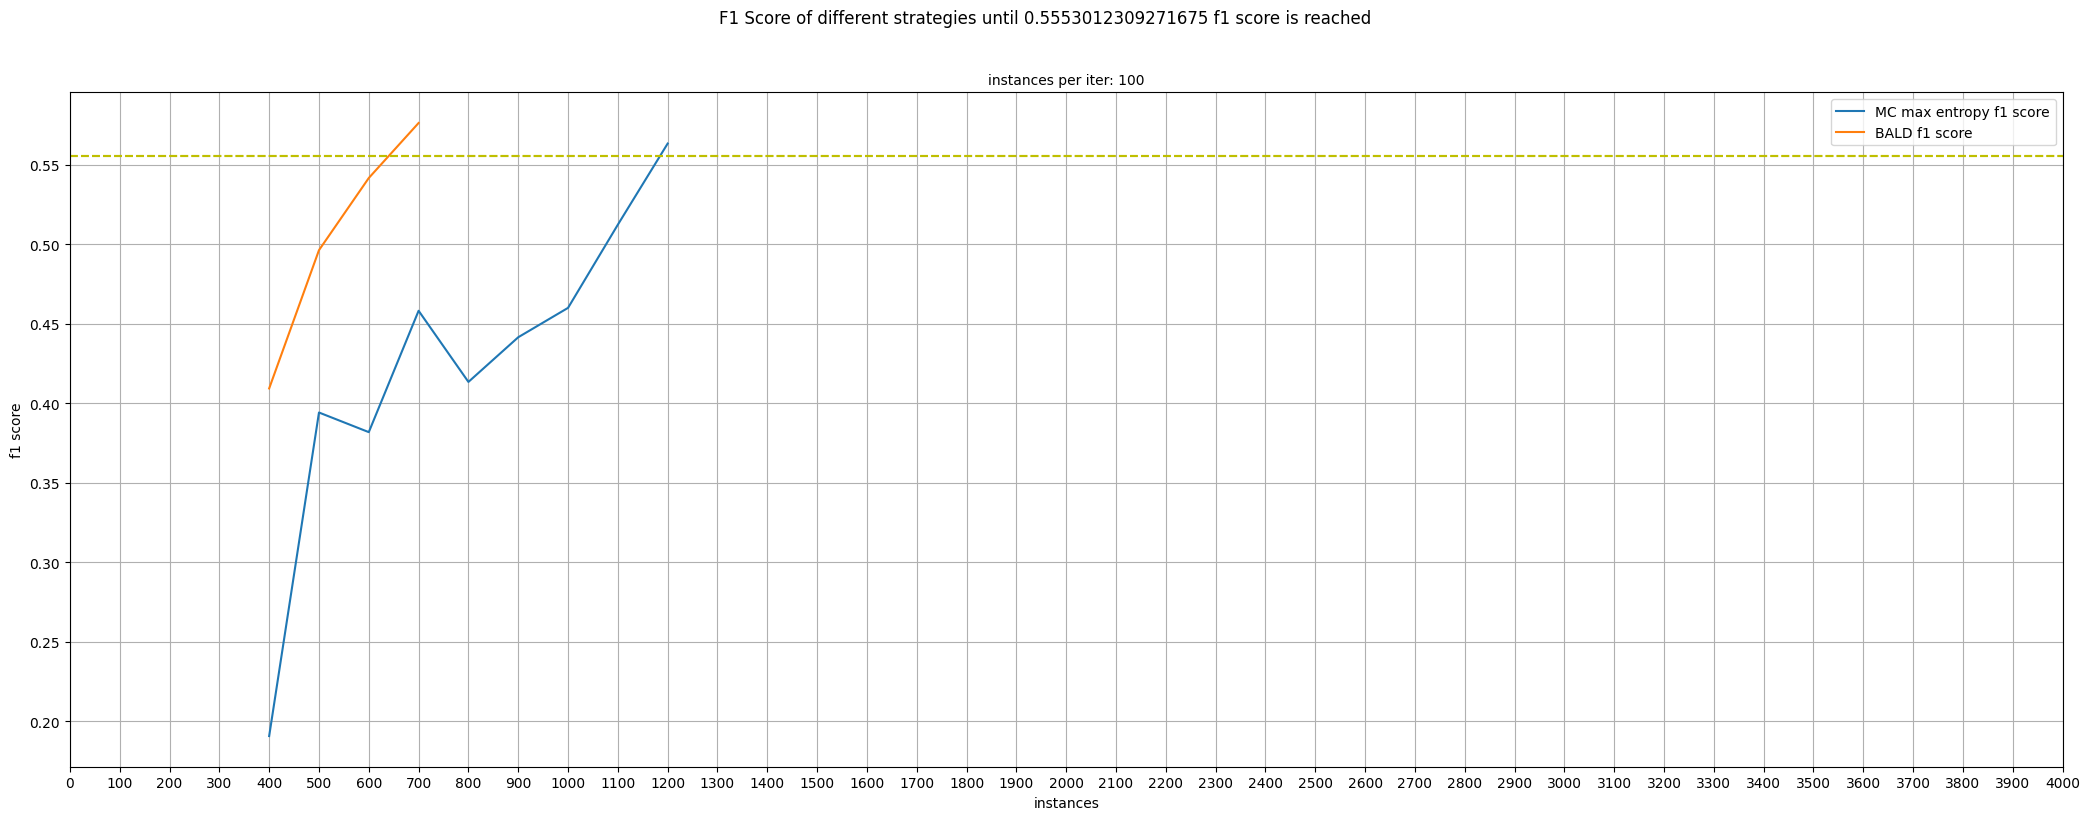

In [9]:
print(scores)


plot_results(
    scores,  # output data frame from strategy_comparison
    n_instances=n_instances,
    tot_samples=len(train_set),  # size of the original training set, for scale
    # goal_acc=goal_acc,
    figsize=(21, 8),
    goal_metric=goal_metric,
    goal_metric_val=goal_f1 if goal_metric == "f1" else goal_acc
)
